In [3]:
import os, sys
import pandas as pd
import numpy as np
import random as rd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set_style('darkgrid')
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import confusion_matrix, classification_report

from sklearn.model_selection import cross_val_score, KFold

from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.naive_bayes import MultinomialNB

In [4]:
df = pd.read_csv('../../data/banknote_authentication.csv')

df.columns = ['variance', 'skewness', 'curtosis', 'entropy', 'class']

In [5]:
X = df.drop('class', axis=1)
Y = df['class']

x_train, x_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.33, random_state=42
)

* kiểm tra và tạo các thư mục (nếu chưa có)
* tập test 33%

In [6]:
scaler = StandardScaler()
x_train = pd.DataFrame(scaler.fit_transform(x_train), columns=X.columns)
x_test = pd.DataFrame(scaler.transform(x_test), columns=X.columns)

In [7]:
classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights_dict = dict(zip(classes, weights))

In [8]:
feature_selection = {
    'LR': X.columns.tolist(),
    'LDA': X.columns.tolist(),
    'DTC': X.columns.tolist(),
    'RD': X.columns.tolist(),
    'KNC': X.columns.tolist(),
    'GNB': X.columns.tolist(),
    'NN': X.columns.tolist(),
    'BG': X.columns.tolist(),
    'NB': X.columns.tolist(),
    'SVM': X.columns.tolist()
}



# 6. Đánh giá và lựa chọn mô hình học máy có giám sát

In [9]:
def check_model(name, model, X, Y, names, results, scoring):
    kfold = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_results = cross_val_score(model, X[feature_selection[name]], Y, cv=kfold, scoring=scoring)
    results.append(cv_results)
    names.append(name)
    msg = scoring.title()+" %s: %.3f%% (%.3f%%)"%(name, cv_results.mean()*100, cv_results.std()*100)
    print(msg)

Accuracy LR: 98.257% (0.533%)
Accuracy LDA: 97.494% (0.438%)
Accuracy DTC: 98.258% (0.799%)
Accuracy RD: 99.346% (0.637%)
Accuracy KNC: 99.673% (0.437%)
Accuracy NB: 83.549% (0.976%)
Accuracy SVM: 99.673% (0.437%)
Accuracy NN: 100.000% (0.000%)
Accuracy BG: 99.346% (0.637%)


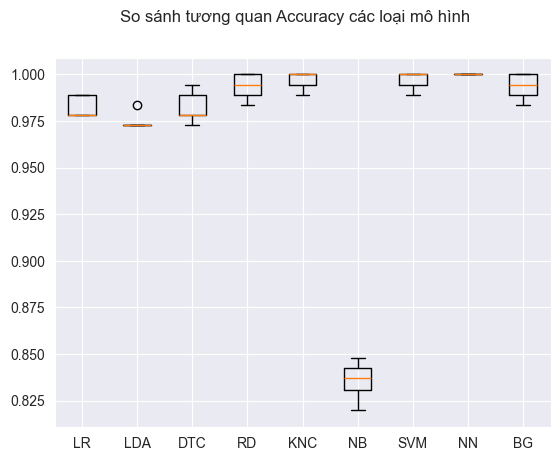

Precision LR: 96.510% (0.993%)
Precision LDA: 94.759% (0.789%)
Precision DTC: 97.879% (1.476%)
Precision RD: 99.099% (1.311%)
Precision KNC: 99.545% (0.909%)
Precision NB: 83.684% (1.571%)
Precision SVM: 99.318% (0.909%)
Precision NN: 100.000% (0.000%)
Precision BG: 99.099% (1.311%)


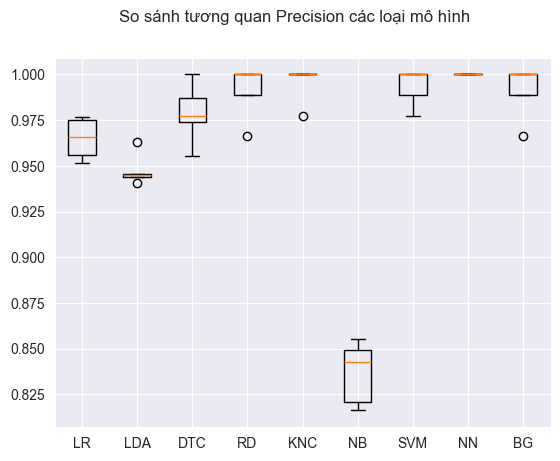

Recall LR: 99.767% (0.465%)
Recall LDA: 100.000% (0.000%)
Recall DTC: 98.280% (1.288%)
Recall RD: 99.494% (1.013%)
Recall KNC: 99.770% (0.460%)
Recall NB: 78.926% (3.513%)
Recall SVM: 100.000% (0.000%)
Recall NN: 100.000% (0.000%)
Recall BG: 99.494% (1.013%)


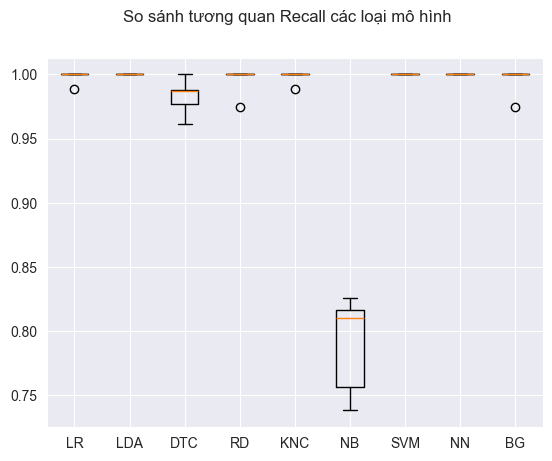

F1 LR: 98.109% (0.553%)
F1 LDA: 97.307% (0.414%)
F1 DTC: 98.068% (0.911%)
F1 RD: 99.286% (0.687%)
F1 KNC: 99.655% (0.460%)
F1 NB: 81.170% (1.637%)
F1 SVM: 99.656% (0.459%)
F1 NN: 100.000% (0.000%)
F1 BG: 99.286% (0.687%)


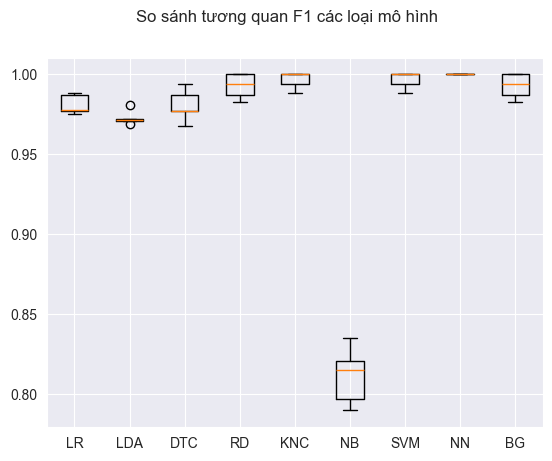

In [10]:
results = []
names = []
scorings = ['accuracy','precision','recall','f1']

for scoring in scorings:
    check_model('LR', LogisticRegression(class_weight=class_weights_dict), x_train, y_train, names, results, scoring)
    check_model('LDA', LinearDiscriminantAnalysis(), x_train, y_train, names, results, scoring)
    check_model('DTC', DecisionTreeClassifier(class_weight=class_weights_dict), x_train, y_train, names, results, scoring)
    check_model('RD', RandomForestClassifier(n_estimators=100, random_state=42, class_weight=class_weights_dict), x_train, y_train, names, results, scoring)
    check_model('KNC', KNeighborsClassifier(n_neighbors=10), x_train, y_train, names, results, scoring)
    check_model('NB', GaussianNB(), x_train, y_train, names, results, scoring)
    check_model('SVM', SVC(class_weight=class_weights_dict), x_train, y_train, names, results, scoring)
    check_model('NN', MLPClassifier(hidden_layer_sizes=(100,), max_iter=500), x_train, y_train, names, results, scoring)
    check_model('BG', GradientBoostingClassifier(), x_train, y_train, names, results, scoring)

    fig = plt.figure()
    fig.suptitle(f'So sánh tương quan {scoring.title()} các loại mô hình')
    ax = fig.add_subplot(111)
    plt.boxplot(results)
    ax.set_xticklabels(names)
    plt.show()

    results = []
    names = []

In [11]:
model = DecisionTreeClassifier(class_weight=class_weights_dict)

supervied_features = x_train[feature_selection['DTC']]
supervied_target = y_train

model.fit(supervied_features, supervied_target)


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,"{np.int64(0): np.float64(0.9107142857142857), np.int64(1): np.float64(1.108695652173913)}"


In [12]:
predictions = model.predict(x_test[feature_selection['DTC']])

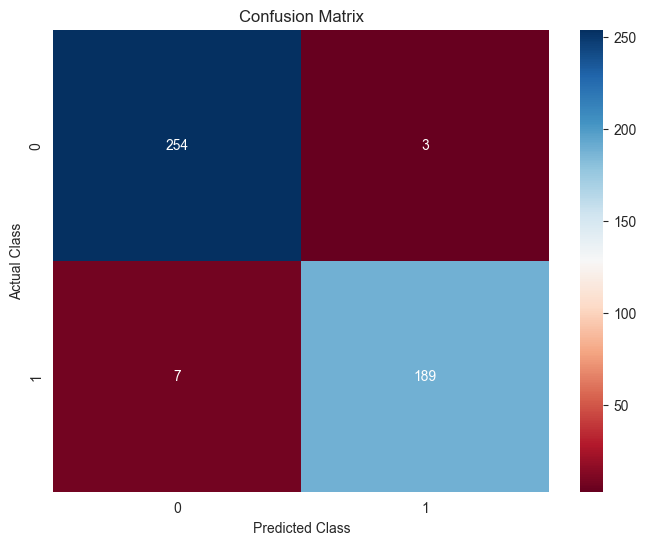

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       257
           1       0.98      0.96      0.97       196

    accuracy                           0.98       453
   macro avg       0.98      0.98      0.98       453
weighted avg       0.98      0.98      0.98       453



In [13]:
conf_matrix = confusion_matrix(y_test, predictions)

plt.figure(figsize=(8,6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap='RdBu')
plt.title("Confusion Matrix")
plt.ylabel("Actual Class")
plt.xlabel("Predicted Class")
plt.show()

print(classification_report(y_test, predictions))

In [18]:
def check_result(pred):
    return "Y" if pred == 1 else "N"

def check_output(stt, model, X_test, Y_test):
    print(f"Lần thứ {stt}: ")
    indx = rd.randint(0, X_test.shape[0] - 1)

    sample = X_test.iloc[indx:indx+1]
    y_predict = model.predict(sample)

    Y_check = check_result(Y_test.iloc[indx])

    print('True:', Y_check)
    print('Predicted:', check_result(y_predict[0]))
    print("----------------------------")

    return Y_check == check_result(y_predict[0])

In [19]:
n_check = 10
solandung = 0

for i in range(n_check):
    if check_output(i+1, model, x_test[feature_selection['DTC']], y_test):
        solandung += 1

print(f"Số lần dự đoán đúng: {solandung} chiếm khoảng {(solandung/n_check)*100}%")


Lần thứ 1: 
True: Y
Predicted: Y
----------------------------
Lần thứ 2: 
True: Y
Predicted: Y
----------------------------
Lần thứ 3: 
True: N
Predicted: N
----------------------------
Lần thứ 4: 
True: N
Predicted: N
----------------------------
Lần thứ 5: 
True: N
Predicted: N
----------------------------
Lần thứ 6: 
True: Y
Predicted: Y
----------------------------
Lần thứ 7: 
True: N
Predicted: N
----------------------------
Lần thứ 8: 
True: Y
Predicted: Y
----------------------------
Lần thứ 9: 
True: Y
Predicted: Y
----------------------------
Lần thứ 10: 
True: N
Predicted: N
----------------------------
Số lần dự đoán đúng: 10 chiếm khoảng 100.0%


In [20]:
solandung = 0

for indx in range(len(x_test)):
    sample = x_test[feature_selection['DTC']].iloc[indx:indx+1]
    y_predict = model.predict(sample)

    Y_check = check_result(y_test.iloc[indx])

    if Y_check == check_result(y_predict[0]):
        solandung += 1

print(f"Số lần dự đoán đúng: {solandung} chiếm khoảng {(solandung/len(x_test))*100}%")

Số lần dự đoán đúng: 443 chiếm khoảng 97.7924944812362%
